In [52]:
import torch
import numpy as np
import pandas as pd
from typing import List
import re
from langchain_core.embeddings import Embeddings
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.stores import InMemoryByteStore
from langchain_core.runnables import RunnablePassthrough, RunnableParallel, RunnableLambda

from langchain.chat_models import init_chat_model
from functools import partial
from langchain_core.output_parsers import StrOutputParser
import json
import uuid
from typing import List, Dict, Any, Set, Tuple

from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from langchain_core.stores import BaseStore
from langchain_core.vectorstores import VectorStore

from langchain_core.prompts import ChatPromptTemplate

from collections import defaultdict
from operator import itemgetter

from Splitters import RecursiveCharacterTextSplitter
from langchain_core.runnables import RunnableSequence
#промпт для части с рассуждением
think_prompt = {'justification':
ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Explain how the justification for bypassing the restriction complies with regulatory documents and the specifics of the case, using only the specified context. Refer to the document path.
You are a professional lawyer working for a large Russian IT company.
Prioritize documents that directly answer the question. Provide clear and precise information in your answer, without unnecessary detail.
Consider the specifics of the case.
Your goal is to accurately answer the user's question.
The problem described in the context should match the problem in the user's question.
Favor sources that directly answer the question.


Context:
{{context}}

Document by User: 
{{text}}

Is this a violation or not?
Your answer:
[/INST]"""
),]),
'base':
ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Explain how the document's content aligns with the regulatory documents and the specifics of the case, using only the specified context. Provide the path to the document.
You are a professional lawyer working for a large Russian IT company.
Prioritize documents that directly answer the question. Provide clear and precise information in your answer, without unnecessary detail.
Consider the specifics of the case.
Your goal is to accurately answer the user's question.
The problem described in the context should match the problem in the user's question.
Favor sources that directly answer the question.


Context:
{{context}}

Document by User: 
{{text}}

Is this a violation or not?
Your answer:
[/INST]"""
),]),
}
#итоговая классификация
final_prompt = ChatPromptTemplate.from_messages([(
    rf"""[INST]
Your primary task is to final and briefly state whether any violations were identified in the analyzed case.
You only answer "yes" or "no," without comment. You don't need to write anything other than "yes" or "no."
Output exactly one word: yes or no
No extra words, punctuation, explanations, or formatting.

Case:
{{text}}

Label: [MASK]
[/INST]"""
),])
#Проверка контекста
is_correct_prompt = ChatPromptTemplate.from_messages([(
    rf"""[INST]
You are a binary classifier.
Your only task: given a question and a context, decide whether the context contains relevant information to answer the question accurately.

Rules:
If a good answer can be formed using the provided context → output yes
If the context is unrelated or insufficient → output no
Output exactly one word: yes or no
No extra words, punctuation, explanations, or formatting.

Now respond only with yes or no for the given input.



Context: 
{{context}}

Prompt: 
{{text}}

Label: [MASK]
[/INST]"""
),])
#отфильтровываем нужные части из контекста
filter_llm_prompt = ChatPromptTemplate.from_messages([(
    rf"""[INST]
You operate in the Russian Federation.
You will be provided with: (1) a legal situation and (2) a block of supporting information containing several articles, laws, or case studies.
Your task is to remove any information from the supporting information that is not relevant to the case being analyzed.
DO NOT provide an answer to the legal question.
Furthermore, you must remove from the context any information that could help answer similar but not identical legal questions, provided that such information does not help answer the user's specific question.
Display only the filtered context. Do not add explanations or comments.


Information to analyze the situation (You work with this part):
{{info}}



A legal situation (You never copy or rewrite this part): 
{{question}}


Filtered information to answer the user's question:
[/INST]"""
),])
#добавление альтернативных формулировок
num_alternate_formulations=4
alter_texts_prompt = ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
- You speak and write only Russian language. You live in Russia.
- Write {num_alternate_formulations} different formulations of the user's text.
- Extract the part of the text that does not contain the user's opinion (the neutral part). If used alone as context, it should allow for a neutral answer to the question.
- Each of your alternative formulations should have the same meaning as the original text, but use different words or word order. The formulations should be clear, concise, neutral and accurately convey the intent.
- Start each formulation on a new paragraph.
- Do not include bias or personal preferences in the formulations.
- Use only Russian text language. Do not write in English.





Text by User: {{text}}

{num_alternate_formulations} formulations:

[/INST]"""
),])

#перевод 
translate_prompt = ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Produce a clear and precise Russian translation that preserves the original meaning of the source text.
If any part of the source text is already in Russian language, keep it exactly as is (do not translate or modify it).
The entire output must be only in Russian language. Do not include any English words, phrases, explanations, or comments.
Use concise, natural, and fluent Russian. Avoid unnecessary additions or omissions.
Remove any text that is not Russian (e.g., English source segments that have been translated, notes, etc.). Only the final Russian language translation should remain.




Text to translate:
{{text}}

Ответ:
[/INST]"""
),])

#выделение неподтверждённых контекстом частей ответа
judge_prompt = ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
You are a strict verifier. Check whether the answer matches the context.

Context:
{{info}}

Question:
{{question}}

Answer:
{{answer}}

Perform the analysis step by step:
1. Highlight all key assertions (claims) in the answer.
2. For each assertion, indicate whether it is supported by the context (supported / contradicted / not_supported).

Print ONLY claim-verdict pairs, without additional text. Each pair begins on a new line:

"claim":"...", "verdict":"...",
...
"claim":"...", "verdict":"..."
[/INST]"""
),])



#исправление цепочки рассуждений в случае малого процента нарушений. 
fix_prompt = ChatPromptTemplate.from_messages([(
    rf"""<s> [INST]
Your task is to correct those parts of the analysis that are not supported by the context in order to provide an analysis that is fully consistent with the documents. Correct the analysis and submit a corrected version.
You are a professional lawyer working for a large Russian IT company.
Consider the specifics of the case.
The problem described in the context should match the problem in the user's question.
Favor sources that directly answer the question.
Those parts that do not need correction, repeat without changes.

Document by User: 
{{question}}

Context:
{{info}}

Previous analysis:
{{text}}

Statements that need to be verified:
{{judge}}

Сorrected analysis:
[/INST]"""
),])

In [53]:
#Эта ячейка просто для создания классов/временных эрзацев из библиотек которые мне нельзя использовать в данный момент


#в университетской, версии у мееня конечно нет ограничений на библиотеки, но на работе комьюнити для меня пока не доступен по бюрократическим, так что сделал вот такой трюк
class MultiVectorRetriever(BaseRetriever):
    vectorstore: VectorStore
    docstore: BaseStore[str, Document]
    id_key: str = "doc_id"
    search_kwargs: Dict[str, Any] = {}
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        doc_hp = self.vectorstore.similarity_search(query, **self.search_kwargs)
        doc_ids: List[str] = []
        for doc in doc_hp:
            if self.id_key in doc.metadata:
                doc_ids.append(doc.metadata[self.id_key])
        doc_ids = list(set(doc_ids))
        docs = self.docstore.mget(doc_ids)
        return [doc for doc in docs if doc is not None]

    async def _aget_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        doc_hp = await self.vectorstore.asimilarity_search(query, **self.search_kwargs)
        doc_ids: List[str] = []
        for i in doc_hp:
            if self.id_key in i.metadata:
                doc_ids.append(i.metadata[self.id_key])

        doc_ids = list(set(doc_ids))
        docs = await self.docstore.amget(doc_ids)
        return [i for i in docs if i is not None]

#пока разбираемся что по эмбедингам нам можно. а что нет написал вот такой заполнитель, по тем же причинам по которым мне не дали просто импортировать MultiVectorRetriever
class AdvancedStatisticalEmbeddings(Embeddings):
    def __init__(self, dim: int = 1536, ngram_range: tuple = (3, 5), seed: int = 42):
        self.dim = dim
        self.ngram_range = ngram_range
        torch.manual_seed(seed)
        np.random.seed(seed)
        self.device = torch.device(DEVICE)

    def _hash(self, s: str) -> int:
        return hash(s) & 0x7FFFFFFF

    def _get_ngrams(self, text: str) -> List[str]:
        text = text.lower().strip()
        ngrams = []
        for n in range(self.ngram_range[0], self.ngram_range[1] + 1):
            for i in range(len(text) - n + 1):
                ngrams.append(text[i:i + n])
        return ngrams

    def _text_to_vector(self, text: str) -> np.ndarray:
        vec = np.zeros(self.dim, dtype=np.float32)
        
        #Word-level
        words = [w for w in text.lower().split() if len(w) > 1]
        for word in words:
            h = self._hash(word) % self.dim
            vec[h] += 1.0
        
        #Char n-grams
        ngrams = self._get_ngrams(text)
        for ng in ngrams:
            h = self._hash(ng) % self.dim
            vec[h] += 0.5
        
        #Простая TF-нормализация
        norm = np.linalg.norm(vec)
        if norm > 0:
            vec = vec / norm
        
        #torch-нормализация
        vec_tensor = torch.from_numpy(vec).to(self.device)
        vec_tensor = torch.nn.functional.normalize(vec_tensor, p=2, dim=0)
        
        return vec_tensor.cpu().numpy()

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return [self._text_to_vector(t).tolist() for t in texts]

    def embed_query(self, text: str) -> List[float]:
        return self._text_to_vector(text).tolist()


In [54]:
#для домашнего тестирования - определяем основные переменные
llm = init_chat_model(
    model="qwen/qwen3-4b-2507",
    model_provider="openai",
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio"
    , temperature=0, top_p=1.0
)

DEVICE = f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu"

embeddings = AdvancedStatisticalEmbeddings(dim=1536)
vectorstore = InMemoryVectorStore(embedding=embeddings)
store = InMemoryByteStore()
#родительско-дочерние 
retriever = MultiVectorRetriever(
    vectorstore=vectorstore, 
    docstore=store, 
    search_kwargs={"k": 10}, 
    id_key="doc_id")
chunk_size=512
i = 0.15
child_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size*i),
    separators=["\n\n", "\n", ". ", "! ", "? ", " ", ""])
chunk_size=2024
parent_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size*i),
    separators=["\n\n", "\n", ". ", "! ", "? ", " ", ""])


file_paths=[
    'contract_lifecycle_stage_1_preparation.json',
    'contract_lifecycle_stage_2_approval.json',
    'contract_lifecycle_stage_3_execution.json',
    'contract_lifecycle_stage_4_closure.json',
    'contract_lifecycle_special_cases.json',
    'contract_lifecycle_hr_documents.json',
    'contract_lifecycle_risk_insurance.json',
    'contract_lifecycle_automation.json',
    'contract_lifecycle_audit.json',
    'contract_lifecycle_special_contracts.json',
    'contract_lifecycle_detailed_procedures.json',
    'contract_lifecycle_escalation_matrix.json',
    'contract_lifecycle_risk_quantification.json',
    'contract_lifecycle_compliance_audit_detailed.json',
    'contract_lifecycle_interaction_with_state.json',
    'contract_lifecycle_template_management.json',
    'contract_lifecycle_termination.json',
    'contract_lifecycle_claims_litigation.json',
    'contract_lifecycle_archiving_erp.json',
    'contract_lifecycle_personal_data_special_cases.json',
]

In [55]:
#работа с документами справочниками
def doc_info_func(record: dict, doc_info: dict) -> dict:
    doc_info["path"] = record.get("path")
    doc_info["section_name"] = record.get("section_name", "")
    doc_info['chapter_name'] = record.get("chapter_name", "")
    doc_info['text'] = record.get("text", "")
    doc_info["doc_id"] = record.get("doc_id")
    return doc_info


def load_docs(file_path: str, parent_splitter: RecursiveCharacterTextSplitter, child_splitter: RecursiveCharacterTextSplitter, metadata_id_key: str):
    #all_tags = []#set()
    #считывание разных типов файлов
    if file_path.endswith(".jsonl"):
        with open(file_path, "r", encoding="utf-8") as f:
            articles = [json.loads(line) for line in f if line.strip()]
    else:
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            if "documents" in data:
                articles = data["documents"]
            else:
                articles = data.get("articles", [])      
    documents = []
    for i in articles:
        page_content = i.get("text", "")
        metadata = {k: v for k, v in i.items() if k != "text"}
        documents.append(Document(page_content=page_content, metadata=metadata))
        
    parent_docs = parent_splitter.split_documents(documents)
    doc_ids = [str(uuid.uuid4()) for _ in parent_docs]
    sub_docs = []
    
    for i, doc in enumerate(parent_docs):
        id = doc_ids[i]
        sd = []

        #if 'summary' in doc.metadata:
        summary = doc.metadata.pop('summary')
        if summary and summary.strip():
            sub_doc = Document(page_content=summary, metadata=doc.metadata.copy())
            sd.append(sub_doc)
        
        sd.extend(child_splitter.split_documents([doc]))
        
        # Прописываем id_key для всех дочерних документов
        for j in sd:
            j.metadata[metadata_id_key] = id
        
        sub_docs.extend(sd)
    
    return parent_docs, sub_docs, doc_ids#, all_tags

#перевод получившихся значений в текст
def merge_contexts(docs: list[list]) -> str:
    #print(docs)
    if docs is None:
        return ""
    elif isinstance(docs, Document):#если вытащен один
        docs = [docs]

    context = []
    for doc in docs:
        #print(doc)
        context.append(
            f"Документ {doc.metadata.get('path', '')} "
            f"({doc.metadata.get('document', '')}):\n "
            f"{doc.page_content}\n"
        )
    return "\n".join(context)



In [56]:
#отбираем документы с наибольшим количеством совпавших тегов,чтобы дать им приоритет
def get_top_k_by_tags(
    documents: List[Document], 
    query: str,
    #all_tags: List[str],
    pattern: re.Pattern
) -> List[Document]:
    found_tags = pattern.findall(query)
    found_tags = set(i.lower() for i in found_tags)
    if not found_tags:
        return []
    itogo = []
    max_sc=1
    for id in documents:
        doc_tags = documents[id]
        if isinstance(doc_tags, str):
            doc_tags = [doc_tags]
        score = len(set(doc_tags) & found_tags)
        if score ==max_sc:
            itogo.append(retriever.docstore.mget([id]))
        elif score > max_sc:
            max_sc=score
            itogo = [retriever.docstore.mget([id])]
    return itogo

In [57]:

#Отбираем документ подтянувшийся чаще остальных на массиве оригинальных и альтернативных формулировок
def sort_contect_f(
    results: List[List[Any]],
    k: int = 64
) -> List[Any]:
    if not results:
        return []
    scores = defaultdict(float)
    doc_by_id = {}
    for docs in results:
        for rank, doc in enumerate(docs):
            i = doc.metadata['doc_id']
            scores[i] += (1.0 / (rank + k))
            doc_by_id.setdefault(i, doc)
    best = sorted(scores.items(), key=itemgetter(1), reverse=True)
    return [doc_by_id[i] for i, _ in best]

#Проверяем контекст моделькой (протестить - смотреть по набору для ускорения)
def is_correct_func(**kwargs):
    chain = (
        is_correct_prompt
        | llm.with_config(configurable={'num_predict': 1})
        | StrOutputParser()
    )
    return chain


#'''для дебага
def debu(x):
    print(x)
    return x


#обработка найденных документов (тест подходит или нет, сжатие, перевод в текст - подумать над обработкой массивом/более умным сжатием)
def process_contexts(
                    query: str, 
                    preproc_cont_chain: RunnableSequence, 
                    k: int,
                    filter_llm_chain: RunnableSequence,
                    doc_tags: Dict[str, List[str]], 
                    pattern: re.Pattern
                ) -> np.array:
    #print(type(doc_tags))
    contexts = (preproc_cont_chain.invoke(query))
    
    #print(contexts)#np.array
    
    cont = get_top_k_by_tags(doc_tags, query, pattern)
    if len(cont)>0:
        contexts=contexts+cont+cont
    contexts = sort_contect_f(contexts)
    #
    #print(len(contexts))
    #Жрет много времени/запросов - не первостепенно учитывая детали реализации,но подумать над ужиманием
    contexts_ls = []
    for i in contexts:
        #print(len(merge_contexts(i)), len(query))
        #print(merge_contexts(i))
        cont_post=merge_contexts(i)
        check = is_correct_func().invoke({
            "context": cont_post,
            "text": query,
        }).lower().strip()[:3]
        if check=='yes':
            contexts_ls.append(filter_llm_chain.invoke({"info": cont_post, 'question': query}))
        l = len(contexts_ls)
        if l >= k:
            break
    else:
        #print('22')
        if l==0:
            for i in (contexts[:k]):
                cont_post=merge_contexts(i)
                contexts_ls.append(filter_llm_chain.invoke({"info": cont_post, 'question': query}))

    contexts_ls = np.array(contexts_ls)
    #if len(contexts_ls) == 0:
    #    
    
    #print(contexts)
    return contexts_ls#

#убрать излишние переходы строки
def split_variants(text: str) -> list[str]:
    while '\n\n' in text:
        text=text.replace('\n\n','\n')
    return text.split('\n')

#подбор альтернативных формулировок
def alter_form_func(**kwargs):
    chain = (
        {"text": RunnablePassthrough()}
        | alter_texts_prompt
        | llm
        | StrOutputParser()
        | split_variants
    )
    return chain
#атавизм
def alter_func(text: str, alter_form_chain: RunnableSequence):#
    #[text] + 
    return alter_form_chain.invoke(text)

#ужимаем контекст до нужного (подумать - уменьшить долю нейронки)
def filter_llm_func(**kwargs):
    chain = (
        filter_llm_prompt
        | llm
        | StrOutputParser()
    )
    return chain




In [58]:
#Аналитика ситуации
def think_func(l='base', **kwargs):
    chain = (
        think_prompt['base']
        | llm
        | StrOutputParser()
    )
    return chain

#оценка утверждений на подтверждённость документами
def judge_func(**kwargs):
    chain = (
        judge_prompt
        | llm
        | StrOutputParser()
    )
    return chain

#рассчет доли подтверждённых
def score_chck(judge: str, score_list: Dict[str, int]={"supported":1,"not_supported":0,  "contradicted":-1}) -> tuple[float, str]:
    score = 0
    mx = 0
    error_lines=[]
    for i in judge.split('\n'):
        i = i.strip()
        verdict = i.split('"verdict":"')[1]
        verdict = verdict.split('"')[0]
        try:
            verdict=score_list[verdict]
        except KeyError:
            verdict=-1
        if verdict<1:
            error_lines.append(i)
        score += verdict
        mx += 1
    return score/mx, '\n'.join(error_lines)

#Исправление ответа (в случае низкой доли требующих корректировку утверждений)
def fix_func(**kwargs):
    chain = (
        fix_prompt
        | llm
        | StrOutputParser()
    )
    return chain

#Итоговая оценка
def final_func(**kwargs):
    chain = (
        final_prompt
        | llm.with_config(configurable={'num_predict': 1})
        | StrOutputParser()
    )
    return chain

#поиск документов контекста
def preproc_cont_func(n:int=3, **kwargs):
    chain = (
        RunnableParallel({
            'user':
                RunnablePassthrough(),
            'alternate':
                partial(
                    alter_func,
                    alter_form_chain = alter_form_func(**kwargs)
                    )
        })
        | (lambda x: [x['user']] + x['alternate'])
        | retriever.map()
        #| partial(sort_contect_f)
        #
        #| debu
        #| (lambda x: x[:n] if len(x) > n else x)
    )
    return chain

In [59]:
#Итоговые конвееры
def process_answer(
            query:str, 
            think_chain: RunnableSequence, 
            preproc_cont_chain: RunnableSequence, 
            judge_chain: RunnableSequence, 
            fix_chain: RunnableSequence, 
            final_chain: RunnableSequence, 
            l:str, 
            k:int, 
            filter_llm_chain: RunnableSequence, 
            doc_tags: Dict[str, List[str]], 
            pattern: re.Pattern
        ) -> tuple[bool, str]:
    pipl_run=True
    sch=0
    #повторять подбор пока нас не удовлетворит доля подтверждённой информации
    while pipl_run and sch<3:
        pipl_run=False
        
        contexts = process_contexts(query, preproc_cont_chain=preproc_cont_chain, k=k+sch, filter_llm_chain=filter_llm_chain, doc_tags=doc_tags, pattern=pattern)
        contexts='\n'.join(contexts)
        #
        #print(contexts)
        result = think_chain.invoke({"context": contexts
                                  , 'text': query
                                  }, l=l)
        #print(result)
        judge=judge_chain.invoke({
                "info":contexts,
                "question":query,
                "answer": result
            })
        i, judge = score_chck(judge)
        sch+=1
        #Проверяем хотим ли мы полностью перегенерировать ответ с расширением контекста (первый) скорректировать его на базе текущего (второй) или оставить без изменений (ни одно из условий)
        if i <0.7 and  sch>=3:
           pipl_run=True
        elif i<1: 
            result=fix_chain.invoke({
                "question":query,
                "info":contexts,
                'text': result,
                'judge':judge
            })

    final_answer = final_chain.invoke({
                "text": result,
            })
    #print(final_answer)
    y=False
    #print(final_answer)
    final_answer=final_answer.strip().lower()[:3]
    if final_answer=='yes':
        y=True
    #для тестирования
    elif final_answer!='no':
        print(query,'final_answer',final_answer)
    #print(result)
    #print(contexts)
    return y, (result + '\n\n' + contexts)



#перевод
def translate_func(**kwargs):
    chain = (
        {"text": RunnablePassthrough()}
        | translate_prompt
        | llm
        
    )
    return chain

#оценка необходимости перевода
def is_translate(text: str) -> bool:
    pattern = re.compile(r'[^\W\d_]+')
    procent_ot = int(len(text)*0.15)
    eng_len = 0
    for i in pattern.finditer(text):
        word = i.group()
        if word.isascii() and word.isalpha():
            eng_len += len(word)
            if eng_len>procent_ot:
                return True
    #print(eng_len,procent_ot)
    return False

def translate_step(answ:(bool, str), **kwargs) -> tuple[bool, str]:
    #print(answ)
    is_val,text= answ
    if is_translate(text):
        return is_val, translate_func().invoke(text).content#(**kwargs)
    else:
        return is_val, text

#долить больше контекста по договору с модификациями пути - вариант по тегам
def pipline_func(l:str, doc_tags: Dict[str, List[str]], pattern: re.Pattern,**kwargs) -> tuple[bool, str]:
    chain = (
        RunnablePassthrough()
        | partial(
            process_answer,
            think_chain=think_func(**kwargs),
            preproc_cont_chain=preproc_cont_func(**kwargs),
            judge_chain=judge_func(**kwargs),
            fix_chain=fix_func(**kwargs),
            final_chain=final_func(**kwargs),
            l=l,
            k=3
            , doc_tags=doc_tags, pattern=pattern
            , filter_llm_chain=filter_llm_func(**kwargs)
        )
        | translate_step
    )
    return chain

In [60]:
all_tags = set()
doc_tags = {}
import glob
for i in glob.glob('storage/*.json'):#file_paths:
    docs, doc_hp, doc_ids = load_docs(i, parent_splitter, child_splitter, "doc_id")#load_docs(i, 1200, 300, "doc_id")
    retriever.vectorstore.add_documents(doc_hp)
    retriever.docstore.mset(list(zip(doc_ids, docs)))
    for id in doc_ids:
        tgs=retriever.docstore.mget([id])[0].metadata.get('tags')
        if id not in doc_tags:
            #doc_tags[tgs].append(id)
            #else:
            doc_tags.update({id:tgs})
        for tg in tgs:
            #tgl=tg.lower()
            all_tags.add(tg)
#Примечание - ближе к релизу докинуть перевод комментария модели
#sort_contect_f
#
all_tags = sorted(all_tags, key=len, reverse=True)
pattern = re.compile('|'.join([re.escape(tag) for tag in all_tags]), re.IGNORECASE)
print(pipline_func(l='base', doc_tags=doc_tags, pattern=pattern).invoke("Дополнительное соглашение №3 к договору аренды здания №А-456 от 01.01.2022. Контрагент - ООО ''НедвижимостьПлюс. Статус проверки и ограничений контрагента - без аванса. Согласующие: 1) Инициатор (руководитель договорного отдела) Белова О.А.: 'Дополнительное соглашение №3 к договору аренды здания №А-456 от 01.01.2022: снижение арендной платы на 25% на 6 месяцев в связи с ''ремонтом, который делает арендодатель, и мы не можем использовать помещение''. Арендодатель – ООО ''НедвижимостьПлюс'', не аффилирован. Приложено письмо арендодателя.'; 2) Юрист Анисимова Т.Р.: 'В договоре п.9.1: ''Снижение арендной платы допускается только при форс-мажоре или существенном изменении обстоятельств''. Ремонт – не форс-мажор. Инициатор утверждает, что ''ремонт делает арендодатель, это его воля, но мы не можем использовать, поэтому это существенное изменение''.'; 3) Финансовый аналитик Круглов С.В.: 'Снижение на 6 месяцев даст экономию 3 млн руб. Это выгодно. Но налоговый риск: если налоговая решит, что это нерыночная сделка (25% – слишком много), могут доначислить налог на прибыль (экономия необоснованна). Юридический департамент требует экспертизу.'; 4) Налоговый юрист (внешний): 'Риск средний. Рекомендую снизить не более чем на 15%. Инициатор согласовал с арендодателем 15%. ДС переделано. Подписано 10.04.2024.'; Подписант: Генеральный директор, подпись 10.04.2024, вступление в силу 15.04.2024."))

(False, 'Путь: /documents/ds_3_to_contract_A456_2024.pdf\n\nНет, это не нарушение.\n\nДополнительное соглашение соответствует внутреннему регламенту, указанному в контексте:\n\n— Подготовлен и рассмотрен внутренне протокол разногласий юридическим, финансовым и направлением департаментами, как требуется по пункту 2 контекста;\n— Юридический департамент установил, что снижение арендной платы не связано с форс-мажором, однако считает его обстоятельством существенного изменения обстоятельств, что соответствует условию договора (стр. 9.1), позволяющему снижать арендную плату в таких случаях;\n— Финансовый департамент признал экономическую выгоду (3 млн рублей), но указал на налоговый риск, что потребовало дополнительного рассмотрения;\n— Внешний налоговый юрист рекомендовал максимально возможное снижение на 15%, что было принято инициатором и включено в пересмотренное соглашение;\n— Окончательное решение было принято генеральным директором, как требуется для критически важных соглашений (пу

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)
import time

def evaluate_model(excel_path, name='test ', d_type='d_type', query_col='query', label_col='true_label'):
    df = pd.read_csv(excel_path)#
    
    y_pred = []
    detailed_responses = []
    
    #print(len(df))
    print(name)
    for idx, row in df.iterrows():
        #print(row[d_type], row[query_col])
        #чуть жалею свой компьютер ценой скорости
        time.sleep(35)
        try:
            # Вызов модели
            tf, details = pipline_func(l='base', doc_tags=doc_tags, all_tags=all_tags, pattern=pattern).invoke(str(row[d_type]+':\n\n'+row[query_col]))
            y_pred.append(tf)
            detailed_responses.append(details)
        except Exception as e:
            print(f"except {idx} - {e}")
            #сменил на более параноидальный вариант при нехватке ресурсов на обработку
            y_pred.append(True)
            #Мысль - возвращать найденный контекст
            detailed_responses.append("ERROR")
    df['predicted_label'] = np.array(y_pred, dtype=bool)
    
    tn, fp, fn, tp = confusion_matrix(df[label_col], df['predicted_label']).ravel()
    #accuracy - нам не подходил из-за дисбаланса классов, в рабочей это перекос в пользу отсутствия нарушений, в синтетике дисбаланс не настолько значим, но последствия пропуска всё-таки перевешивают "проверку лишнего документа"
    #f1_score - в итоге решили взять за приоритетный
    print(name)
    print(f"f1: {f1_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    
    print(f"confusion_matrix:\n TN={tn}, FP={fp}\n FN={fn}, TP={tp}")
    print(f"precision: {precision_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    print(f"recall: {recall_score(df[label_col], df['predicted_label'], zero_division=0):.4f}")
    print(f"matthew: {matthews_corrcoef(df[label_col], df['predicted_label']):.4f}")
    print(classification_report(df[label_col], df['predicted_label'], target_names=['Нет нарушения', 'Нарушение']))
    

    df['model_response'] = detailed_responses
    df.to_csv(f"predict_{name}.csv", index=False)
    


evaluate_model("test_queries.csv")

test 


ПЕРВАЯ КОНТРОЛЬНАЯ ТОЧКА

Модель - Qwen3 4B 2507

test 
f1: 0.6763
confusion_matrix:
 TN=74, FP=38
 FN=29, TP=70
precision: 0.6481
recall: 0.7071
matthew: 0.3672
               precision    recall  f1-score   support

Нет нарушения       0.72      0.66      0.69       112
    Нарушение       0.65      0.71      0.68        99

     accuracy                           0.68       211
    macro avg       0.68      0.68      0.68       211
 weighted avg       0.69      0.68      0.68       211



Примерно в трети случаев возводим напраслину на договор и с такой же вероятностью упускаем нарушение (на рабочих данные похуже, так как в случае с синтетикой было сложнее не оставлять ему подсказок), что обещает нам большое количество документов которые потребуется перепроверить ручным методом. 
С другой стороны, тактически выгоднее сперва повысить точность выявления нарушений (Recall), возможно компенсируя это тем что мы запускаем модель не на всем объеме документов, а на уже попавших в зону подозрения, чтобы сократить их число. Таким образом это уже база под потенциальное применение, а потом при доработке и повышении  (Precision) уже можно будет расширить его действие.

Ближайшие цели - анализ промежуточных результатов для ошибок.
Поиграть с переформулировками запроса для облегчения задачи РАГ и возможно пост или пред обработкой контекста.
Поиграть с вытягиванием по тегу и (работой над формой ввода)

Модель:
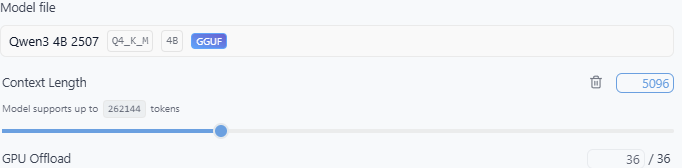

ВТОРАЯ ВЕРСИЯ


test 
test 
f1: 0.7042
confusion_matrix:
 TN=73, FP=39
 FN=24, TP=75
precision: 0.6579
recall: 0.7576
matthew: 0.4099
               precision    recall  f1-score   support

Нет нарушения       0.75      0.65      0.70       112
    Нарушение       0.66      0.76      0.70        99

     accuracy                           0.70       211
    macro avg       0.71      0.70      0.70       211
 weighted avg       0.71      0.70      0.70       211

 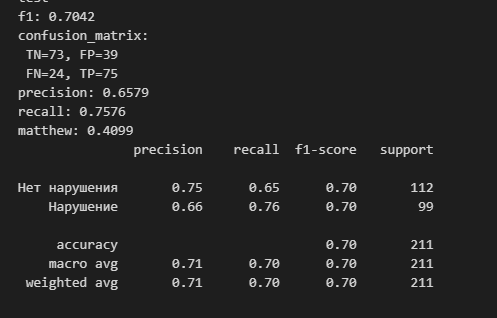
